In [1]:
import os
from mistralai import Mistral
import os
import json
import random
import time

In [2]:
api_key = "ujI60UR6Fe5jel48SAtfnMiN5Skxfwhq"
#kostenlloses model
model =  "open-mistral-nemo"
client = Mistral(api_key=api_key)

Generate Subontologies

In [7]:
# === File paths ===
input_path = r"C:\Users\cdoering\OneDrive - IW\Dokumente\Capstone\CapstoneDATEV25-1\competency_questions_output\clustered_CQs_with_promoted_and_reviewed_noise.json"
output_file_path = "ontology_output/ontology_from_clustered_cqs.json"
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

# === Load clustered CQs ===
with open(input_path, "r", encoding="utf-8") as f:
    clustered_cqs = json.load(f)

# === Filter: exclude 'Cluster -1' and keep first 10 clusters ===
filtered_clusters = {
    k: v for k, v in sorted(clustered_cqs.items())
    if k != "Cluster -1"
}
selected_clusters = dict(list(filtered_clusters.items())[:20])

# === System Prompt ===
ontology_system_prompt = """
You are an expert legal ontology engineer.

Your task is to extract ontology components from the given legal ruling text (German court decisions). 
Identify and return three structured components:

1. **Classes**: Legal entities or concepts (e.g., Urteil, Entscheidungsgründe, Anspruch, Person, Tatbestand, Eiwendung, Rubrum, Tenor)
2. **Properties**: Verbs or phrases representing relationships or attributes (e.g., beinhaltet, basiert auf, verhindert, erörtern)
3. **Relationships**: Triples (Subject)-(Predicate)-(Object), connecting two classes using a property

Requirements:
- Only extract concepts if they have relationships.
- Use clear legal language in German.
- The CQs are the purpose of the ontology:  
The ontology must contain exactly the legal knowledge needed to enable a meaningful and structured answer to that question!
- Output must follow this structure (example):

{
  "classes": ["Urteil", "Anspruch", "Tatbestand"],
  "properties": ["beinhaltet", "basiert auf"],
  "relationships": [
    ["Urteil", "beinhaltet", "Tatbestand"],
    ["Anspruch", "basiert auf", "Tatbestand"]
  ]
}

## Few-Shot Examples 
"Sentence: 'Ein Arbeitnehmer hat eine Sozialversicherungsnummer'"
"Classes: [Arbeitnehmner, Sozialversicherungsnummer]"
"Properties: [hatIdentifikation]"
"Relationship: [(Arbeitnehmer)-(hatIdentifikation)-(Sozialversicherungsnummer)]"

"Sentence: 'Arbeitnehmer haben nach Gesetz einen geregelten Mindestanspruch auf 24 Tage Urlaub im Jahr'"
"Classes: [Arbeitnehmer, Urlaub]"
"Properties: [hatMindestAnspruchAuf]"
"Relationship: [(Arbeitnehmer)-(hatMindestAnspruchAuf)-(Urlaub)]"

## Modelling Guidelines
- **Concept Identification**:
  - Identify nouns and noun phrases as potential **Classes**.
  - Identify verbs and verb phrases as potential **Properties**.
  - Identify prepositions that establish relationships between nouns.

- **Classes**:
  - Represent concepts in the domain, not the words that denote these concepts.
  - Avoid creating classes for synonyms; use a single class for concepts with the same meaning.

- **Properties**:
  - Represent significant relationships or attributes between classes.
  - Should be meaningful and represent a significant connection.

- **Relationships**:
  - Establish connections between classes using properties.
  - Ensure relationships are meaningful within the domain context.

- **General Principles**:
  - There is no single correct way to model a domain; the best solution depends on the application.
  - Ontology development is an iterative process; refine as needed.
  - Avoid cycles in the class hierarchy.
  - Siblings in the hierarchy should be at the same level of generality.

## Naming Conventions
**General**:
- Do not add strings like 'class', 'domain', 'range', 'property', or 'slot' to names.
- Use consistent naming throughout the ontology.

**Classes**:
- Names are always capitalized.
- Use nouns or compound nouns (e.g., Vertrag, Arbeit, Arbeitsvertrag).
- Use singular over plural (e.g., Arbeitsvertrag instead of Arbeitsverträge).
- Avoid abbreviations (e.g., Arbeitgeber instead of AG).

**Properties**:
- Names start with a lower-case letter.
- Use verbs or verb phrases.
- Can contain nouns in CamelCase starting with a verb (e.g., hatAnspruchAuf).
- Do not include spaces, commas, asterisks, or special characters.

## Finally
- Ensure that you include empty lists for classes, properties, or relationships if none are found.
- Make sure all extracted components, i.e. classes, properties, and relationships as well as all descriptions are in German and translate where necessary.
- Include a class only if at least one relationship is found for a class. Verify this requirement.
- Check carefully for each class without any relationship, based on the name and the description of the class, if it can be merged with another class or if it is actually a relationship between one class and another. This is particularly relevant for classes that are named in the form of 'has something'.
- All ontology components must be in German language!
- Terms like 'range' or 'domain' are never allowed!

## Additional Relevance Criteria
While extracting ontology components, give preference to those concepts and relations that help answer the following legal competency questions:

- Was muss man als Eigentümer alles rechtlich tun, damit man ein Grundstück verkaufen kann?
- Was sind die Voraussetzungen für die Übertragung eines Grundstücks?
- Welche Ansprüche stehen dem Geschädigten eines Verkehrsunfalls zu?
- Welche Möglichkeiten bestehen, sich von einem geschlossenen Kaufvertrag nachträglich zu lösen?

These questions serve as guidance to ensure the ontology supports realistic legal queries in downstream applications such as a legal dashboard.
"""


# === Prompt Builder ===
def build_prompt(cq_list):
    questions = "\n".join(f"- {entry['cq']}" for entry in cq_list)
    return f"Extract ontology components from the following set of legal competency questions:\n\n{questions}"

# === Main loop ===
ontology_results = {}

for cluster_id, cq_list in selected_clusters.items():
    prompt = build_prompt(cq_list)
    try:
        response = client.chat.complete(
            model=model,
            messages=[
                {"role": "system", "content": ontology_system_prompt},
                {"role": "user", "content": prompt}
            ],
            temperature=0.5
        )
        content = response.choices[0].message.content.strip()
        try:
            ontology = json.loads(content)

            # ✅ Nur Triplets akzeptieren
            relationships = ontology.get("relationships", [])
            if isinstance(relationships, list) and all(
                isinstance(r, list) and len(r) == 3 for r in relationships
            ):
                ontology_results[cluster_id] = {
                    "competency_questions": [entry["cq"] for entry in cq_list],
                    "ontology": ontology
                }
                print(f"✅ Ontology extracted for {cluster_id}")
            else:
                print(f"❌ Invalid triplets in relationships for {cluster_id}")

        except json.JSONDecodeError:
            print(f"❌ Invalid JSON for {cluster_id}")
    except Exception as e:
        print(f"❌ Error for {cluster_id}: {e}")
    time.sleep(1)

# === Save results ===
with open(output_file_path, "w", encoding="utf-8") as f_out:
    json.dump(ontology_results, f_out, indent=2, ensure_ascii=False)

print("✅ Ontology extraction per cluster completed.")


✅ Ontology extracted for Cluster 0
❌ Invalid triplets in relationships for Cluster 1
❌ Invalid JSON for Cluster 10
❌ Invalid JSON for Cluster 100
✅ Ontology extracted for Cluster 101
✅ Ontology extracted for Cluster 102
✅ Ontology extracted for Cluster 103
✅ Ontology extracted for Cluster 104
❌ Invalid JSON for Cluster 105
✅ Ontology extracted for Cluster 106
✅ Ontology extracted for Cluster 107
✅ Ontology extracted for Cluster 108
✅ Ontology extracted for Cluster 109
✅ Ontology extracted for Cluster 11
✅ Ontology extracted for Cluster 110
✅ Ontology extracted for Cluster 111
✅ Ontology extracted for Cluster 112
✅ Ontology extracted for Cluster 113
❌ Invalid triplets in relationships for Cluster 114
✅ Ontology extracted for Cluster 115
✅ Ontology extraction per cluster completed.


Generalize Subontologies using generalized CQs

In [8]:
# === Load generated ontologies and GCQs ===
with open("ontology_output/ontology_from_clustered_cqs.json", "r", encoding="utf-8") as f:
    detailed_ontologies = json.load(f)

with open("generalized_questions_SE.json", "r", encoding="utf-8") as f:
    generalized_questions = json.load(f)

# === System Prompt for Ontology Generalization ===
ontology_refinement_prompt = """
You are a legal ontology abstraction expert.

Your task is to revise a detailed legal ontology so that it aligns with and enables answering the **generalized legal question (GCQ)** it is based on.

The purpose of the ontology is to serve as a semantic foundation for answering legal questions like the GCQ. Therefore:

- Remove elements that are overly specific, instance-based, or tied to individual cases.
- Generalize class and property names wherever possible, while preserving legal clarity.
- Retain only legally meaningful and relevant concepts.
- Ensure that the ontology reflects the abstraction level of the GCQ and contains the necessary concepts to support its answering.

Guidelines:
- All content must be in **German**.
- Only return valid JSON. Do not add any comments or explanations.
- Always return the following keys:
  - "classes": [...],
  - "properties": [...],
  - "relationships": [[Subject, Property, Object], ...]

If no content applies, return empty lists.

Think like a legal knowledge modeler:
Abstract from examples, preserve legal semantics, and ensure the resulting ontology is sufficient to answer the generalized legal question.
"""

# === Output dictionary for generalized ontologies ===
generalized_ontologies = {}

# === Process each cluster ===
for cluster_id, data in detailed_ontologies.items():
    gcq = generalized_questions.get(cluster_id, "")
    ontology = data["ontology"]

    user_input = {
        "generalized_question": gcq,
        "ontology": ontology
    }

    try:
        response = client.chat.complete(
            model=model,
            messages=[
                {"role": "system", "content": ontology_refinement_prompt},
                {"role": "user", "content": json.dumps(user_input, ensure_ascii=False)}
            ],
            temperature=0.5
        )

        content = response.choices[0].message.content.strip()
        try:
            refined = json.loads(content)
            generalized_ontologies[cluster_id] = {
                "generalized_question": gcq,
                "generalized_ontology": refined
            }
            print(f"✅ Generalized ontology for {cluster_id}")
        except json.JSONDecodeError:
            print(f"❌ Invalid JSON for {cluster_id}")
    except Exception as e:
        print(f"❌ Error for {cluster_id}: {e}")
    time.sleep(1)

# === Save final generalized ontologies ===
with open("ontology_output/generalized_ontology_per_gcq.json", "w", encoding="utf-8") as f_out:
    json.dump(generalized_ontologies, f_out, indent=2, ensure_ascii=False)

print("✅ Generalized ontologies saved.")


✅ Generalized ontology for Cluster 0
✅ Generalized ontology for Cluster 101
✅ Generalized ontology for Cluster 102
✅ Generalized ontology for Cluster 103
✅ Generalized ontology for Cluster 104
✅ Generalized ontology for Cluster 106
✅ Generalized ontology for Cluster 107
✅ Generalized ontology for Cluster 108
✅ Generalized ontology for Cluster 109
✅ Generalized ontology for Cluster 11
✅ Generalized ontology for Cluster 110
✅ Generalized ontology for Cluster 111
✅ Generalized ontology for Cluster 112
✅ Generalized ontology for Cluster 113
✅ Generalized ontology for Cluster 115
✅ Generalized ontologies saved.


Visualize Subontologies

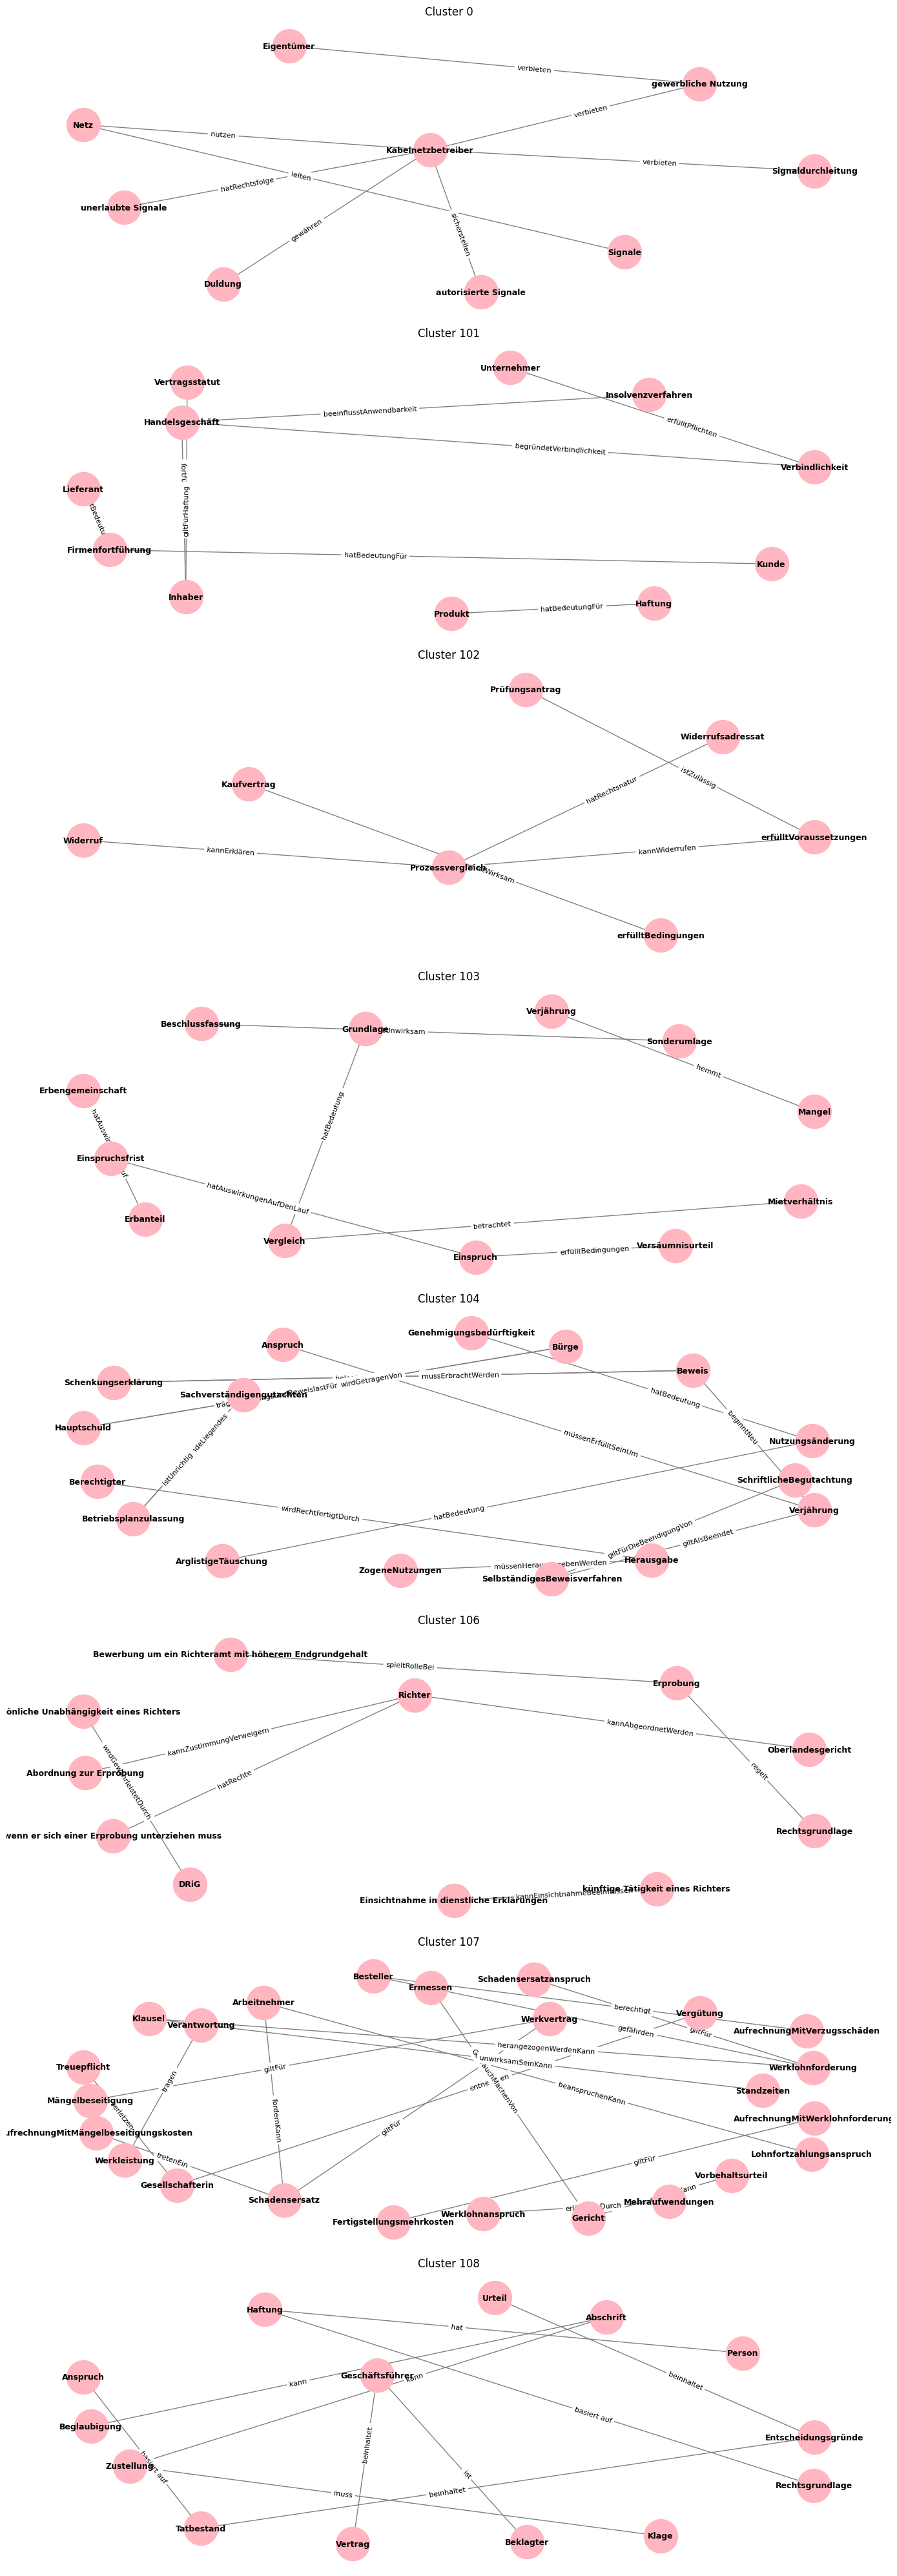

In [9]:
import json
import os
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# === Load ontology data ===
ontology_path = "ontology_output/ontology_from_clustered_cqs.json"
with open(ontology_path, "r", encoding="utf-8") as f:
    ontology_data = json.load(f)

# === Config ===
num_graphs = 8
cols = 1
rows = num_graphs

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]

# === Draw graphs ===
for i, (cluster_id, cluster_data) in enumerate(list(ontology_data.items())[:num_graphs]):
    ontology = cluster_data.get("ontology", {})
    relationships = ontology.get("relationships", [])

    G = nx.DiGraph()
    used_classes = set()

    # Nur verknüpfte Klassen einfügen
    for rel in relationships:
        if isinstance(rel, list) and len(rel) == 3:
            subj, pred, obj = rel
            G.add_edge(subj, obj, label=pred)
            used_classes.update([subj, obj])
    G.add_nodes_from(used_classes)

    if len(G.nodes) == 0:
        continue

    # Spring-Layout mit stärkerer Entzerrung
    pos = nx.spring_layout(G, k=2.0, seed=42)  # k > 1 = mehr Abstand

    ax = axes[i]
    ax.set_title(f"{cluster_id}", fontsize=12)

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color="lightpink", node_size=1400)

    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_size=9, font_weight="bold")

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color="gray", arrows=True, arrowsize=15)

    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=8, ax=ax, label_pos=0.6)

    ax.axis("off")

# === Clean up unused subplots ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === Save as PDF ===
plt.tight_layout()
plt.savefig("ontologien_visualisiert.pdf", bbox_inches="tight")
plt.show()   

Visualize Generalized Subontologies

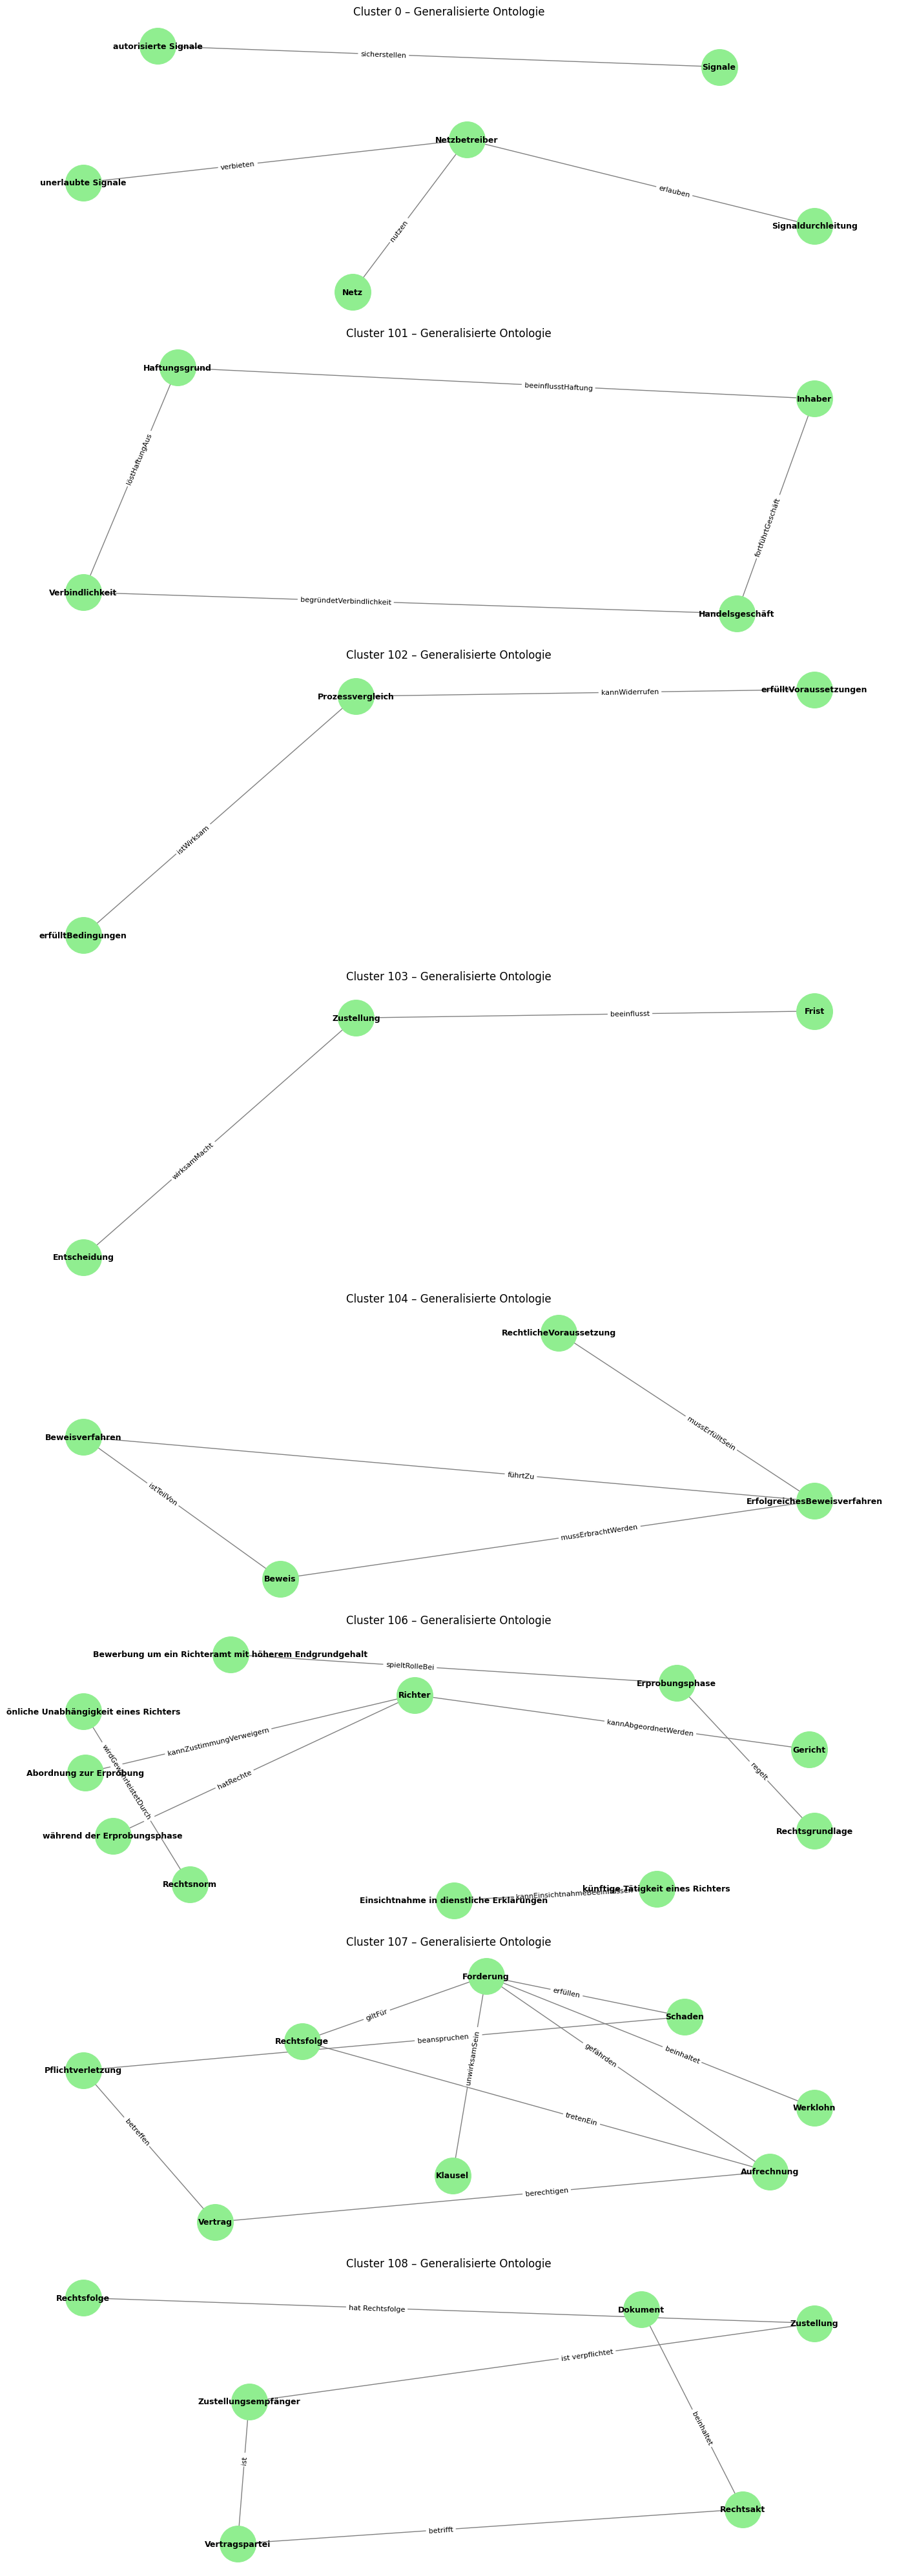

In [ ]:
# === Load generalized ontology data ===
generalized_path = "ontology_output/generalized_ontology_per_gcq.json"
with open(generalized_path, "r", encoding="utf-8") as f:
    generalized_data = json.load(f)

# === Config ===
num_graphs = min(8, len(generalized_data))  # Maximal 8 Graphen anzeigen
cols = 1
rows = num_graphs

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = np.atleast_1d(axes)  # Falls nur ein Graph → in Array umwandeln

# === Zeichne jede Ontologie einzeln ===
for i, (cluster_id, cluster_data) in enumerate(list(generalized_data.items())[:num_graphs]):
    ontology = cluster_data.get("generalized_ontology", {}).get("ontology", {})
    G = nx.DiGraph()

    # Nur verknüpfte Klassen hinzufügen
    used_classes = set()
    for rel in ontology.get("relationships", []):
        if isinstance(rel, list) and len(rel) == 3:
            subj, pred, obj = rel
            G.add_edge(subj, obj, label=pred)
            used_classes.update([subj, obj])
    G.add_nodes_from(used_classes)

    if len(G.nodes) == 0:
        continue

    # Spring-Layout mit starkem Abstand für Klarheit
    pos = nx.spring_layout(G, k=2.0, seed=42)

    ax = axes[i]
    ax.set_title(f"{cluster_id} – Generalisierte Ontologie", fontsize=12)

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color="lightgreen", node_size=1600)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color="gray", arrows=True, arrowsize=15)

    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=8, ax=ax, label_pos=0.6)

    ax.axis("off")

# === Save and show ===
plt.tight_layout()
plt.savefig("generalized_ontologies_verbessert.pdf", bbox_inches="tight")
plt.show()


Visualize Generalized Ontologies next to Original Ontologies 

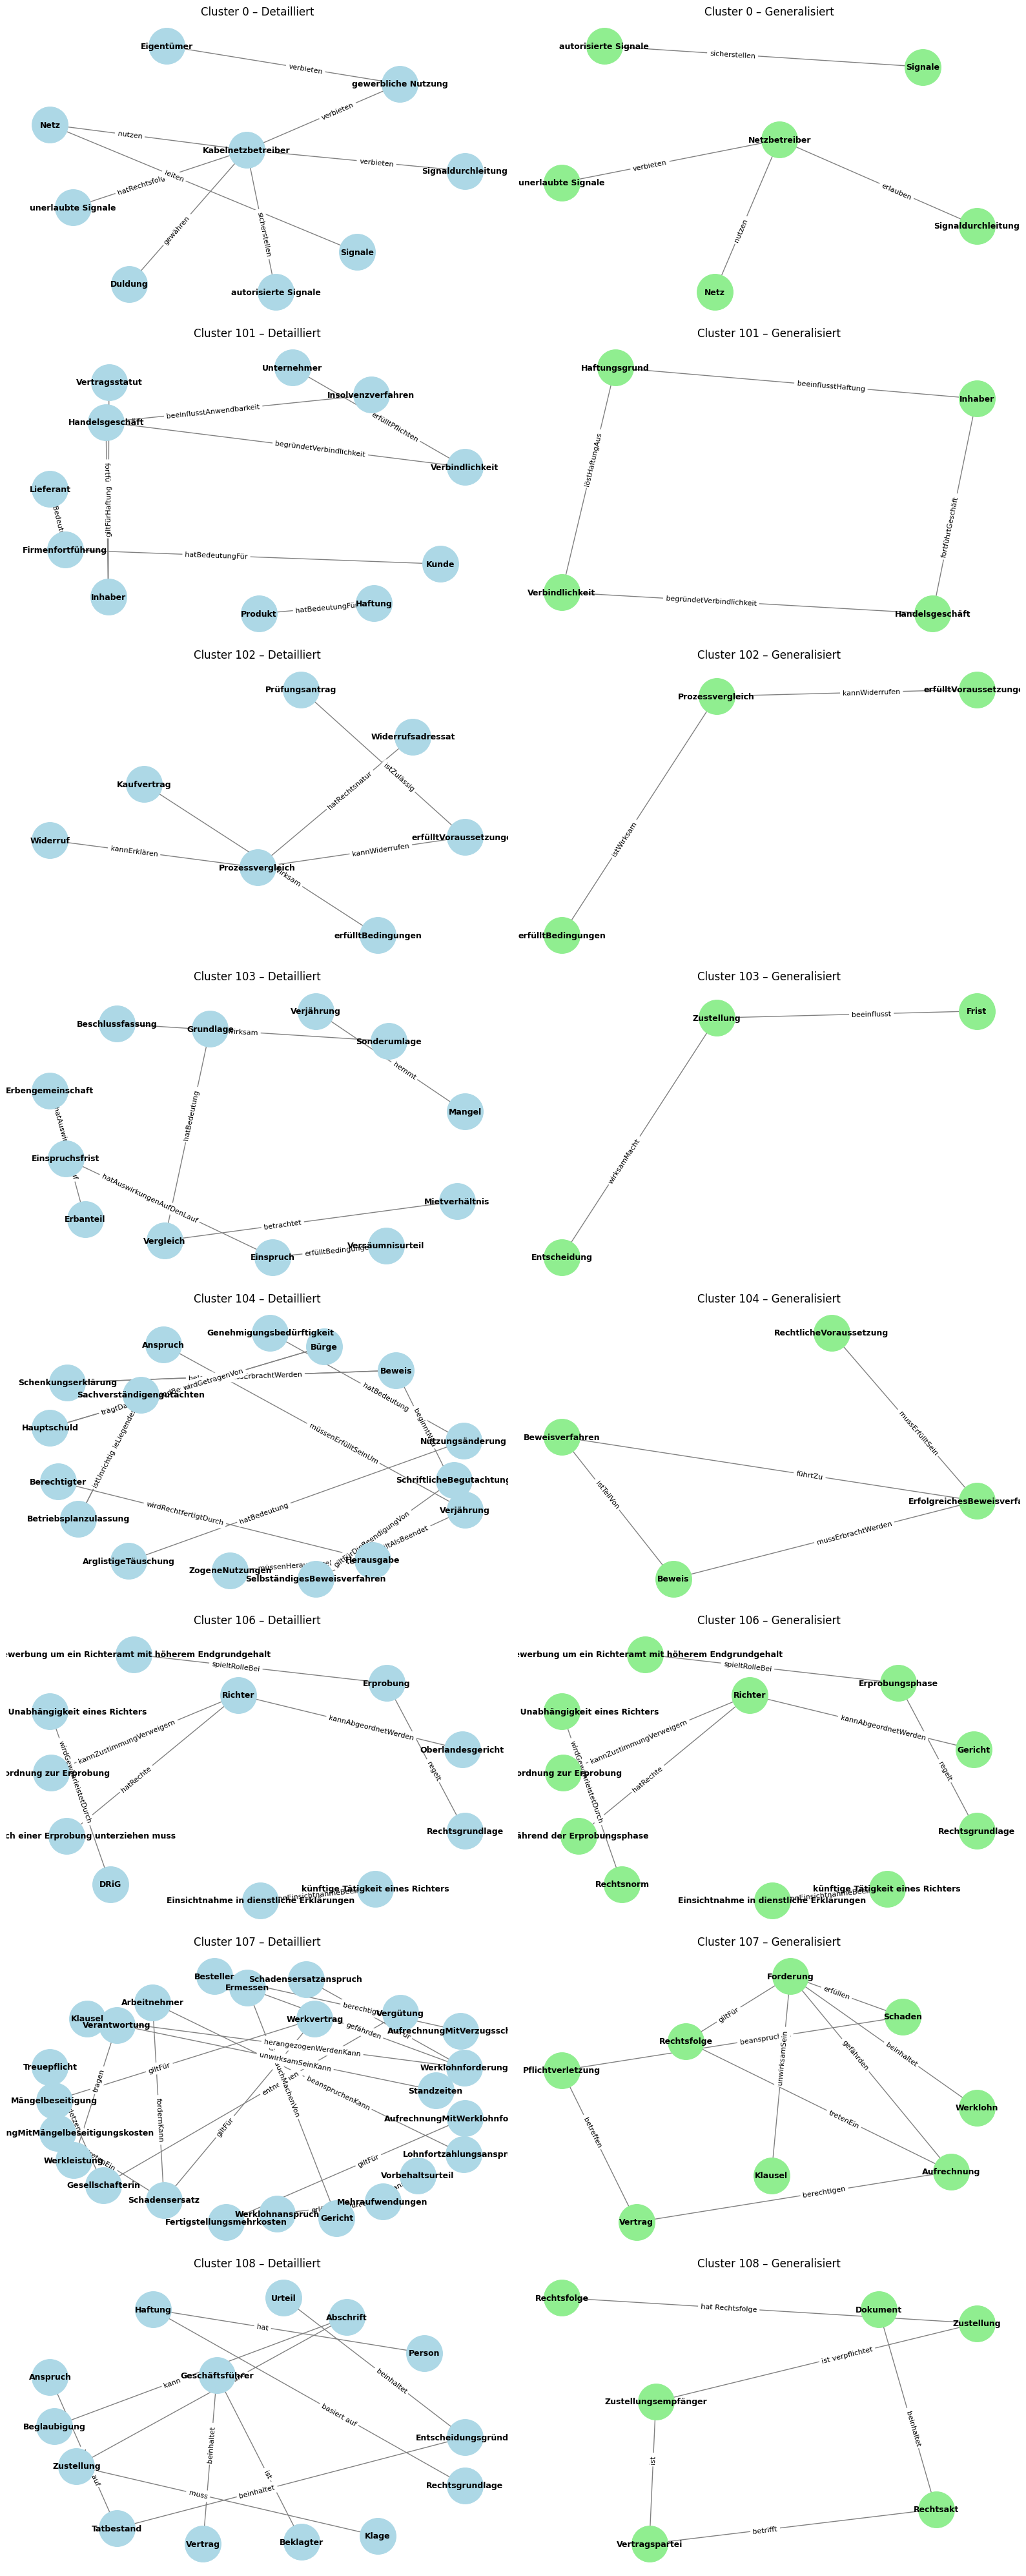

In [11]:
#import json
import os
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# === Load ontology data ===
detailed_path = "ontology_output/ontology_from_clustered_cqs.json"
generalized_path = "ontology_output/generalized_ontology_per_gcq.json"

with open(detailed_path, "r", encoding="utf-8") as f:
    detailed_data = json.load(f)

with open(generalized_path, "r", encoding="utf-8") as f:
    generalized_data = json.load(f)

# === Config ===
num_graphs = min(8, len(generalized_data))  # Maximal 8 Cluster vergleichen
cols = 2  # 1x detailliert, 1x generalisiert
rows = num_graphs

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = np.atleast_2d(axes)  # Immer 2D Array, auch bei nur 1 Zeile

# === Draw detailed and generalized side-by-side ===
for i, cluster_id in enumerate(list(generalized_data.keys())[:num_graphs]):
    # === DETAILED ONTOLOGY ===
    detailed = detailed_data.get(cluster_id, {}).get("ontology", {})
    G1 = nx.DiGraph()
    used_nodes1 = set()
    for rel in detailed.get("relationships", []):
        if isinstance(rel, list) and len(rel) == 3:
            G1.add_edge(rel[0], rel[2], label=rel[1])
            used_nodes1.update([rel[0], rel[2]])
    G1.add_nodes_from(used_nodes1)

    pos1 = nx.spring_layout(G1, k=2.0, seed=42)
    ax1 = axes[i][0]
    ax1.set_title(f"{cluster_id} – Detailliert", fontsize=12)
    nx.draw_networkx_nodes(G1, pos1, ax=ax1, node_color="lightblue", node_size=1600)
    nx.draw_networkx_labels(G1, pos1, ax=ax1, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G1, pos1, ax=ax1, edge_color="gray", arrows=True, arrowsize=15)
    edge_labels1 = nx.get_edge_attributes(G1, "label")
    nx.draw_networkx_edge_labels(G1, pos1, edge_labels=edge_labels1, font_size=8, ax=ax1, label_pos=0.6)
    ax1.axis("off")

    # === GENERALIZED ONTOLOGY ===
    generalized = generalized_data.get(cluster_id, {}).get("generalized_ontology", {}).get("ontology", {})
    G2 = nx.DiGraph()
    used_nodes2 = set()
    for rel in generalized.get("relationships", []):
        if isinstance(rel, list) and len(rel) == 3:
            G2.add_edge(rel[0], rel[2], label=rel[1])
            used_nodes2.update([rel[0], rel[2]])
    G2.add_nodes_from(used_nodes2)

    pos2 = nx.spring_layout(G2, k=2.0, seed=42)
    ax2 = axes[i][1]
    ax2.set_title(f"{cluster_id} – Generalisiert", fontsize=12)
    nx.draw_networkx_nodes(G2, pos2, ax=ax2, node_color="lightgreen", node_size=1600)
    nx.draw_networkx_labels(G2, pos2, ax=ax2, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G2, pos2, ax=ax2, edge_color="gray", arrows=True, arrowsize=15)
    edge_labels2 = nx.get_edge_attributes(G2, "label")
    nx.draw_networkx_edge_labels(G2, pos2, edge_labels=edge_labels2, font_size=8, ax=ax2, label_pos=0.6)
    ax2.axis("off")

# === Save and show ===
plt.tight_layout()
plt.savefig("vergleich_detailliert_vs_generalisiert_verbessert.pdf", bbox_inches="tight")
plt.show()
